# Notebook 2 — Implementacao do KNN e Comparacao de Resultados
## Wine Quality Dataset
**Disciplinas:** Matematica para Computacao | IA e suas Aplicacoes | Fundamentos de Programacao | Fundamentos de Logica

Este notebook implementa o algoritmo KNN de duas formas:
1. **Implementacao Manual** — do zero, sem bibliotecas prontas (apenas Python/math/collections)
2. **Implementacao com sklearn** — usando a biblioteca scikit-learn
3. **Comparacao dos resultados** entre as duas abordagens

> **Pre-requisito:** execute o Notebook 1 primeiro para gerar os arquivos de dados preparados.

---

## 1. Importacao das Bibliotecas

Importamos apenas o necessario em cada etapa:
- **Implementacao Manual**: somente `math` e `collections` (Python puro — sem sklearn, sem numpy para o algoritmo)
- **Implementacao sklearn**: apenas o necessario da biblioteca
- As demais bibliotecas sao para carregamento de dados e visualizacao

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math
from collections import Counter

# Sklearn - usado SOMENTE na etapa de implementacao com biblioteca (secao 3)
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, ConfusionMatrixDisplay)

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 100
print("Bibliotecas carregadas!")

Bibliotecas carregadas!


## 2. Carregamento dos Dados Preparados

Utilizamos os arquivos gerados pelo Notebook 1: dados filtrados e parametros de normalizacao.

In [17]:
# Carrega os dados preparados pelo Notebook 1
df = pd.read_csv("wine_quality_filtrado.csv")
params = pd.read_csv("normalizacao_params.csv")
idx_treino = np.load("indices_treino.npy")
idx_teste  = np.load("indices_teste.npy")

feature_names = list(df.columns[:-1])  # todas exceto 'qualidade_binaria'
print(f"Dataset preparado: {df.shape[0]} amostras x {df.shape[1]} colunas")
print(f"Features ({len(feature_names)}): {feature_names}")
print(f"Variavel alvo: qualidade_binaria  |  Classes: {df['qualidade_binaria'].unique()}")
df.head()

Dataset preparado: 6497 amostras x 12 colunas
Features (11): ['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol']
Variavel alvo: qualidade_binaria  |  Classes: [0. 1.]


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,qualidade_binaria
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,0.0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,0.0
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,0.0
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,0.0
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,0.0


In [18]:
# Separar X (features) e y (alvo) em arrays numpy
X = df.drop(columns=['qualidade_binaria']).values
y = df['qualidade_binaria'].values

# Recriar divisao treino/teste com os MESMOS indices do Notebook 1 (reproducibilidade)
X_train_raw, X_test_raw = X[idx_treino], X[idx_teste]
y_train,      y_test     = y[idx_treino], y[idx_teste]

# Recriar normalizacao com os parametros salvos pelo Notebook 1
media_treino  = params['media'].values
desvio_treino = params['desvio'].values

X_train_norm = (X_train_raw - media_treino) / desvio_treino
X_test_norm  = (X_test_raw  - media_treino) / desvio_treino

print(f"Treino: {len(X_train_raw)} amostras  |  Teste: {len(X_test_raw)} amostras")
print(f"Distribuicao no treino  - Boa: {y_train.sum()} ({y_train.mean()*100:.1f}%) | Ruim: {(1-y_train).sum()} ({(1-y_train).mean()*100:.1f}%)")
print(f"Distribuicao no teste   - Boa: {y_test.sum()} ({y_test.mean()*100:.1f}%) | Ruim: {(1-y_test).sum()} ({(1-y_test).mean()*100:.1f}%)")

Treino: 5197 amostras  |  Teste: 1300 amostras
Distribuicao no treino  - Boa: 1028.0 (19.8%) | Ruim: 4169.0 (80.2%)
Distribuicao no teste   - Boa: 249.0 (19.2%) | Ruim: 1051.0 (80.8%)


## 3. Implementacao Manual do KNN (sem bibliotecas prontas)

O algoritmo **K-Nearest Neighbors (KNN)** classifica um novo ponto com base nas K amostras
de treino mais proximas a ele.

### Base matematica — Distancia Euclidiana

Para dois pontos $A$ e $B$ em um espaco $n$-dimensional:

$$d(A, B) = \sqrt{\sum_{i=1}^{n}(a_i - b_i)^2}$$

### Logica do algoritmo:
1. Calcular a distancia de um ponto de teste para **todos** os pontos de treino
2. Ordenar as distancias e selecionar os **K menores** (vizinhos mais proximos)
3. **Votacao majoritaria**: a classe mais frequente entre os K vizinhos e a previsao
4. Repetir para todos os pontos de teste

### Estruturas de programacao utilizadas:
| Estrutura | Onde e utilizada |
|-----------|-----------------|
| Variaveis numericas | Acumular soma de quadrados, contar acertos, armazenar acuracia |
| Listas | Guardar pares (distancia, classe) de todos os pontos de treino |
| `for` (repeticao) | Percorrer pontos de treino, percorrer pontos de teste, percorrer dimensoes |
| `if` (condicional) | Verificar acertos ao calcular acuracia manualmente |
| Funcoes | Modularizar o codigo: distancia, classificacao de um ponto, classificacao do conjunto |
| Ordenacao (`sort`) | Encontrar os K vizinhos mais proximos |
| `Counter` (colecoes) | Contar votos de cada classe entre os vizinhos |


In [19]:
# ================================================================
#  IMPLEMENTACAO MANUAL DO KNN - SEM SKLEARN OU BIBLIOTECAS PRONTAS
#  Usa apenas: math, collections.Counter e Python nativo
# ================================================================

def distancia_euclidiana(ponto_a, ponto_b):
    '''
    Calcula a Distancia Euclidiana entre dois pontos n-dimensionais.

    Formula: d(A, B) = sqrt( sum( (a_i - b_i)^2 ) )

    Estruturas usadas:
        - Variavel numerica (soma_quadrados): acumulador
        - Repeticao (for): percorre cada dimensao
        - math.sqrt: raiz quadrada (Python nativo)

    Parametros:
        ponto_a (list): coordenadas do ponto A
        ponto_b (list): coordenadas do ponto B
    Retorna:
        float: distancia euclidiana entre A e B
    '''
    soma_quadrados = 0.0  # variavel numerica: acumula os quadrados das diferencas

    # Estrutura de repeticao: percorre cada dimensao dos dois pontos ao mesmo tempo
    for a_i, b_i in zip(ponto_a, ponto_b):
        diferenca = a_i - b_i          # subtracao entre as coordenadas
        soma_quadrados += diferenca ** 2  # eleva ao quadrado e acumula

    return math.sqrt(soma_quadrados)   # raiz quadrada da soma total


def knn_classificar_ponto(X_treino, y_treino, ponto_novo, k):
    '''
    Classifica UM unico ponto usando KNN puro (sem bibliotecas).

    Passos:
        1. Calcular distancia do ponto_novo para todos os pontos de treino
        2. Ordenar e selecionar os K menores (vizinhos mais proximos)
        3. Votacao majoritaria para decidir a classe

    Estruturas usadas:
        - Lista (distancias): armazena (distancia, classe) de cada ponto de treino
        - Repeticao (for range): percorre todos os pontos de treino
        - .sort(): ordena por distancia
        - Fatiamento [:k]: seleciona os K primeiros
        - Counter.most_common: votacao majoritaria

    Parametros:
        X_treino (list de listas): atributos do conjunto de treino
        y_treino (list): classes do conjunto de treino
        ponto_novo (list): atributos do ponto a classificar
        k (int): numero de vizinhos a considerar
    Retorna:
        int: classe prevista (0 = ruim, 1 = boa)
    '''
    # Lista que vai armazenar pares (distancia, classe) para cada ponto de treino
    distancias = []

    # Estrutura de repeticao: calcula a distancia do ponto_novo a cada ponto de treino
    for i in range(len(X_treino)):
        dist = distancia_euclidiana(ponto_novo, X_treino[i])
        distancias.append((dist, y_treino[i]))   # adiciona par (distancia, classe) na lista

    # Ordena a lista pelo primeiro elemento de cada tupla (a distancia)
    # key=lambda: funcao anonima que diz para ordenar pelo indice 0 da tupla
    distancias.sort(key=lambda par: par[0])

    # Seleciona apenas os K primeiros elementos da lista ordenada (K vizinhos mais proximos)
    k_vizinhos = distancias[:k]

    # Extrai somente as classes dos vizinhos (descarta as distancias com _)
    classes_vizinhos = [classe for _, classe in k_vizinhos]

    # Votacao majoritaria: Counter conta quantas vezes cada classe aparece
    # most_common(1) retorna o par [(classe, contagem)] da mais frequente
    votos = Counter(classes_vizinhos)
    classe_prevista = votos.most_common(1)[0][0]

    return classe_prevista


def knn_prever_conjunto(X_treino, y_treino, X_teste, k):
    '''
    Aplica knn_classificar_ponto para todos os pontos do conjunto de teste.

    Estruturas usadas:
        - Lista (previsoes): armazena a predicao de cada ponto
        - Repeticao (for): percorre todos os pontos de teste

    Parametros:
        X_treino (list): atributos de treino
        y_treino (list): classes de treino
        X_teste (list): atributos de teste
        k (int): numero de vizinhos
    Retorna:
        list: lista com a classe prevista para cada ponto de teste
    '''
    previsoes = []   # lista que acumulara as predicoes

    # Estrutura de repeticao: repete para cada ponto do conjunto de teste
    for ponto in X_teste:
        pred = knn_classificar_ponto(X_treino, y_treino, ponto, k)
        previsoes.append(pred)   # adiciona a predicao na lista

    return previsoes


def calcular_acuracia_manual(y_real, y_previsto):
    '''
    Calcula a acuracia comparando cada previsao com o valor real.

    Estruturas usadas:
        - Variavel numerica (acertos): contador
        - Repeticao (for): percorre todas as amostras
        - Condicional (if): verifica se acertou

    Parametros:
        y_real (list): classes reais
        y_previsto (list): classes previstas pelo modelo
    Retorna:
        float: acuracia (proporcao de acertos)
    '''
    acertos = 0  # variavel numerica contadora

    # Estrutura de repeticao: compara cada par (real, previsto)
    for real, previsto in zip(y_real, y_previsto):
        if real == previsto:   # estrutura condicional: acertou?
            acertos += 1       # incrementa o contador

    return acertos / len(y_real)   # proporcao de acertos

print("Todas as funcoes do KNN Manual definidas com sucesso!")
print("  - distancia_euclidiana(ponto_a, ponto_b)")
print("  - knn_classificar_ponto(X_treino, y_treino, ponto_novo, k)")
print("  - knn_prever_conjunto(X_treino, y_treino, X_teste, k)")
print("  - calcular_acuracia_manual(y_real, y_previsto)")

Todas as funcoes do KNN Manual definidas com sucesso!
  - distancia_euclidiana(ponto_a, ponto_b)
  - knn_classificar_ponto(X_treino, y_treino, ponto_novo, k)
  - knn_prever_conjunto(X_treino, y_treino, X_teste, k)
  - calcular_acuracia_manual(y_real, y_previsto)


In [20]:
# Teste rapido da distancia euclidiana para validacao
# Caso simples: distancia entre (0,0) e (3,4) deve ser 5 (triangulo pitagorico)
d_teste = distancia_euclidiana([0, 0], [3, 4])
print(f"Teste da distancia Euclidiana:")
print(f"  d([0,0], [3,4]) = {d_teste:.4f}  (esperado: 5.0000) -> {'OK' if abs(d_teste-5) < 0.001 else 'ERRO'}")

# Caso adicional: ponto identico deve ter distancia 0
d_zero = distancia_euclidiana([1, 2, 3], [1, 2, 3])
print(f"  d([1,2,3], [1,2,3]) = {d_zero:.4f}  (esperado: 0.0000) -> {'OK' if d_zero == 0 else 'ERRO'}")

Teste da distancia Euclidiana:
  d([0,0], [3,4]) = 5.0000  (esperado: 5.0000) -> OK
  d([1,2,3], [1,2,3]) = 0.0000  (esperado: 0.0000) -> OK


In [21]:
# Execucao do KNN Manual com K=5 (valor inicial)
# Usamos uma subamostra para a versao manual pois sua complexidade e O(n*m):
# cada ponto de teste calcula distancia para TODOS os pontos de treino.
# Sem otimizacoes, isso e lento em datasets grandes.

TAMANHO_TREINO = 500   # amostras de treino para a versao manual
TAMANHO_TESTE  = 200   # amostras de teste

np.random.seed(42)
idx_am = np.random.choice(len(X_train_norm), TAMANHO_TREINO, replace=False)

# Convertemos para listas Python (nossa implementacao nao usa operacoes numpy)
X_train_m = X_train_norm[idx_am].tolist()
y_train_m = y_train[idx_am].tolist()
X_test_m  = X_test_norm[:TAMANHO_TESTE].tolist()
y_test_m  = y_test[:TAMANHO_TESTE].tolist()

print(f"Executando KNN Manual (K=5)...")
print(f"  Treino: {len(X_train_m)} amostras | Teste: {len(X_test_m)} amostras")

K_INICIAL = 5
previsoes_k5 = knn_prever_conjunto(X_train_m, y_train_m, X_test_m, K_INICIAL)
acuracia_k5  = calcular_acuracia_manual(y_test_m, previsoes_k5)

acertos_k5 = sum(1 for r, p in zip(y_test_m, previsoes_k5) if r == p)
print(f"\nResultado com K={K_INICIAL}:")
print(f"  Acertos: {acertos_k5} de {len(y_test_m)}")
print(f"  Acuracia: {acuracia_k5:.4f} ({acuracia_k5*100:.2f}%)")

Executando KNN Manual (K=5)...
  Treino: 500 amostras | Teste: 200 amostras

Resultado com K=5:
  Acertos: 150 de 200
  Acuracia: 0.7500 (75.00%)


In [22]:
# Teste com diferentes valores de K — KNN Manual
# Objetivo: identificar o K que maximiza a acuracia
# Valores impares sao preferidos para evitar empate na votacao

print("Testando diferentes valores de K (KNN Manual)...")
print(f"{'K':>4}  {'Acertos':>8}  {'Acuracia':>10}")
print("-" * 28)

valores_k_manual = [1, 3, 5, 7, 9, 11]
resultados_manual = {}

for k_val in valores_k_manual:
    preds = knn_prever_conjunto(X_train_m, y_train_m, X_test_m, k_val)
    acc   = calcular_acuracia_manual(y_test_m, preds)
    acertos_k = sum(1 for r, p in zip(y_test_m, preds) if r == p)
    resultados_manual[k_val] = acc
    print(f"{k_val:>4}  {acertos_k:>8}  {acc:>9.4f} ({acc*100:.2f}%)")

melhor_k_manual = max(resultados_manual, key=resultados_manual.get)
print(f"\nMelhor K (manual): K={melhor_k_manual} -> Acuracia: {resultados_manual[melhor_k_manual]*100:.2f}%")

Testando diferentes valores de K (KNN Manual)...
   K   Acertos    Acuracia
----------------------------
   1       152     0.7600 (76.00%)
   3       151     0.7550 (75.50%)
   5       150     0.7500 (75.00%)
   7       146     0.7300 (73.00%)
   9       149     0.7450 (74.50%)
  11       148     0.7400 (74.00%)

Melhor K (manual): K=1 -> Acuracia: 76.00%


## 4. Implementacao do KNN com Biblioteca scikit-learn

Agora usamos o `KNeighborsClassifier` do scikit-learn, que:
- Usa **KD-Tree** internamente (muito mais rapido que O(n*m))
- Permite treinar com **todo o dataset** (nao apenas 500 amostras)
- Oferece metricas completas de avaliacao automaticamente
- Possui hiperparametros ajustaveis: `n_neighbors`, `metric`, `weights`, `algorithm`

A implementacao matematica e a mesma que fizemos manualmente — Distancia Euclidiana + votacao majoritaria.
A diferenca e a eficiencia e os recursos adicionais da biblioteca.


In [23]:
# Normalizacao com StandardScaler (equivalente ao nosso Z-score manual)
# fit_transform no treino: aprende media e desvio e ja transforma
# transform no teste: aplica OS MESMOS parametros aprendidos no treino
scaler     = StandardScaler()
X_train_sk = scaler.fit_transform(X_train_raw)
X_test_sk  = scaler.transform(X_test_raw)

print("Normalizacao com StandardScaler:")
print(f"  X_train: shape={X_train_sk.shape} | media~0: {X_train_sk.mean():.6f} | desvio~1: {X_train_sk.std():.6f}")
print(f"  X_test:  shape={X_test_sk.shape}")

Normalizacao com StandardScaler:
  X_train: shape=(5197, 11) | media~0: 0.000000 | desvio~1: 1.000000
  X_test:  shape=(1300, 11)


In [24]:
# Modificacao de hiperparametros: testando diferentes valores de K
print("Testando diferentes valores de K (KNN sklearn - dataset completo)...")
print(f"{'K':>4}  {'Acuracia':>10}  {'Precisao':>10}  {'Recall':>8}")
print("-" * 40)

valores_k_sk = [1, 3, 5, 7, 9, 11, 15, 21]
resultados_sklearn = {}

for k_val in valores_k_sk:
    # Cria o modelo com o valor de K e metrica Euclidiana
    knn = KNeighborsClassifier(n_neighbors=k_val, metric='euclidean')
    knn.fit(X_train_sk, y_train)      # treina
    preds = knn.predict(X_test_sk)    # prediz

    from sklearn.metrics import precision_score, recall_score
    acc  = accuracy_score(y_test, preds)
    prec = precision_score(y_test, preds, zero_division=0)
    rec  = recall_score(y_test, preds, zero_division=0)

    resultados_sklearn[k_val] = acc
    print(f"{k_val:>4}  {acc:>10.4f}  {prec:>10.4f}  {rec:>8.4f}")

melhor_k_sk = max(resultados_sklearn, key=resultados_sklearn.get)
print(f"\nMelhor K (sklearn): K={melhor_k_sk} -> Acuracia: {resultados_sklearn[melhor_k_sk]*100:.2f}%")

Testando diferentes valores de K (KNN sklearn - dataset completo)...
   K    Acuracia    Precisao    Recall
----------------------------------------
   1      0.8615      0.6219    0.7068
   3      0.8431      0.5889    0.5984
   5      0.8454      0.5984    0.5863
   7      0.8385      0.5816    0.5582
   9      0.8415      0.5923    0.5542
  11      0.8408      0.5921    0.5422
  15      0.8362      0.5865    0.4900
  21      0.8423      0.6222    0.4498

Melhor K (sklearn): K=1 -> Acuracia: 86.15%


In [25]:
# Impacto de outros hiperparametros alem do K
print("Impacto de diferentes hiperparametros (K=melhor_k_sk):")
print(f"{'Configuracao':<40}  {'Acuracia':>10}")
print("-" * 55)

configs = [
    {'n_neighbors': melhor_k_sk, 'metric': 'euclidean', 'weights': 'uniform'},
    {'n_neighbors': melhor_k_sk, 'metric': 'euclidean', 'weights': 'distance'},
    {'n_neighbors': melhor_k_sk, 'metric': 'manhattan', 'weights': 'uniform'},
    {'n_neighbors': melhor_k_sk, 'metric': 'chebyshev', 'weights': 'uniform'},
]

for cfg in configs:
    knn_cfg = KNeighborsClassifier(**cfg)
    knn_cfg.fit(X_train_sk, y_train)
    acc_cfg = accuracy_score(y_test, knn_cfg.predict(X_test_sk))
    label = f"metric={cfg['metric']}, weights={cfg['weights']}"
    print(f"{label:<40}  {acc_cfg:>10.4f}")

Impacto de diferentes hiperparametros (K=melhor_k_sk):
Configuracao                                Acuracia
-------------------------------------------------------
metric=euclidean, weights=uniform             0.8615
metric=euclidean, weights=distance            0.8615
metric=manhattan, weights=uniform             0.8585
metric=chebyshev, weights=uniform             0.8554


In [26]:
# Modelo final com o melhor K para relatorio detalhado
knn_final    = KNeighborsClassifier(n_neighbors=melhor_k_sk, metric='euclidean')
knn_final.fit(X_train_sk, y_train)
y_pred_final = knn_final.predict(X_test_sk)

print(f"=== Relatorio Completo de Classificacao — KNN sklearn (K={melhor_k_sk}) ===\n")
print(classification_report(y_test, y_pred_final,
      target_names=['Ruim (0 - quality < 7)', 'Boa (1 - quality >= 7)']))

=== Relatorio Completo de Classificacao — KNN sklearn (K=1) ===

                        precision    recall  f1-score   support

Ruim (0 - quality < 7)       0.93      0.90      0.91      1051
Boa (1 - quality >= 7)       0.62      0.71      0.66       249

              accuracy                           0.86      1300
             macro avg       0.78      0.80      0.79      1300
          weighted avg       0.87      0.86      0.86      1300



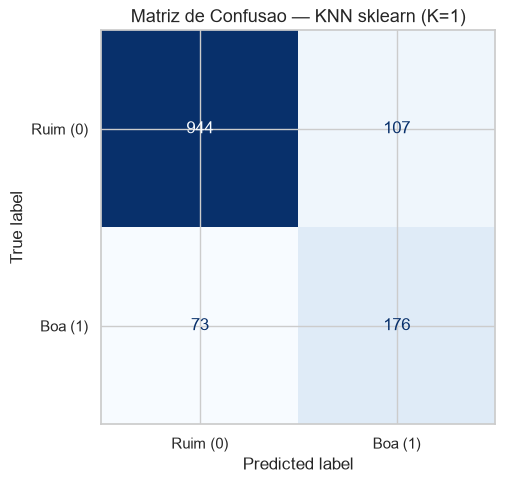

Interpretacao da Matriz de Confusao:
  Verdadeiros Negativos (ruim previsto como ruim):  944
  Falsos Positivos     (ruim previsto como boa) :  107
  Falsos Negativos     (boa previsto como ruim) :   73
  Verdadeiros Positivos (boa previsto como boa) :  176

  Taxa de erro total: 13.85%


In [27]:
# Matriz de confusao
fig, ax = plt.subplots(figsize=(7, 5))
cm = confusion_matrix(y_test, y_pred_final)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=['Ruim (0)', 'Boa (1)'])
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title(f'Matriz de Confusao — KNN sklearn (K={melhor_k_sk})', fontsize=13)
plt.tight_layout()
plt.savefig("knn_matriz_confusao.png", bbox_inches='tight')
plt.show()

vn, fp, fn, vp = cm[0][0], cm[0][1], cm[1][0], cm[1][1]
print("Interpretacao da Matriz de Confusao:")
print(f"  Verdadeiros Negativos (ruim previsto como ruim): {vn:4d}")
print(f"  Falsos Positivos     (ruim previsto como boa) : {fp:4d}")
print(f"  Falsos Negativos     (boa previsto como ruim) : {fn:4d}")
print(f"  Verdadeiros Positivos (boa previsto como boa) : {vp:4d}")
print(f"\n  Taxa de erro total: {(fp+fn)/(vn+fp+fn+vp)*100:.2f}%")

## 5. Comparacao dos Resultados

Comparamos as duas implementacoes considerando:
- **Facilidade de implementacao**
- **Diferencas nos resultados** (acuracia, escopo de dados, velocidade)


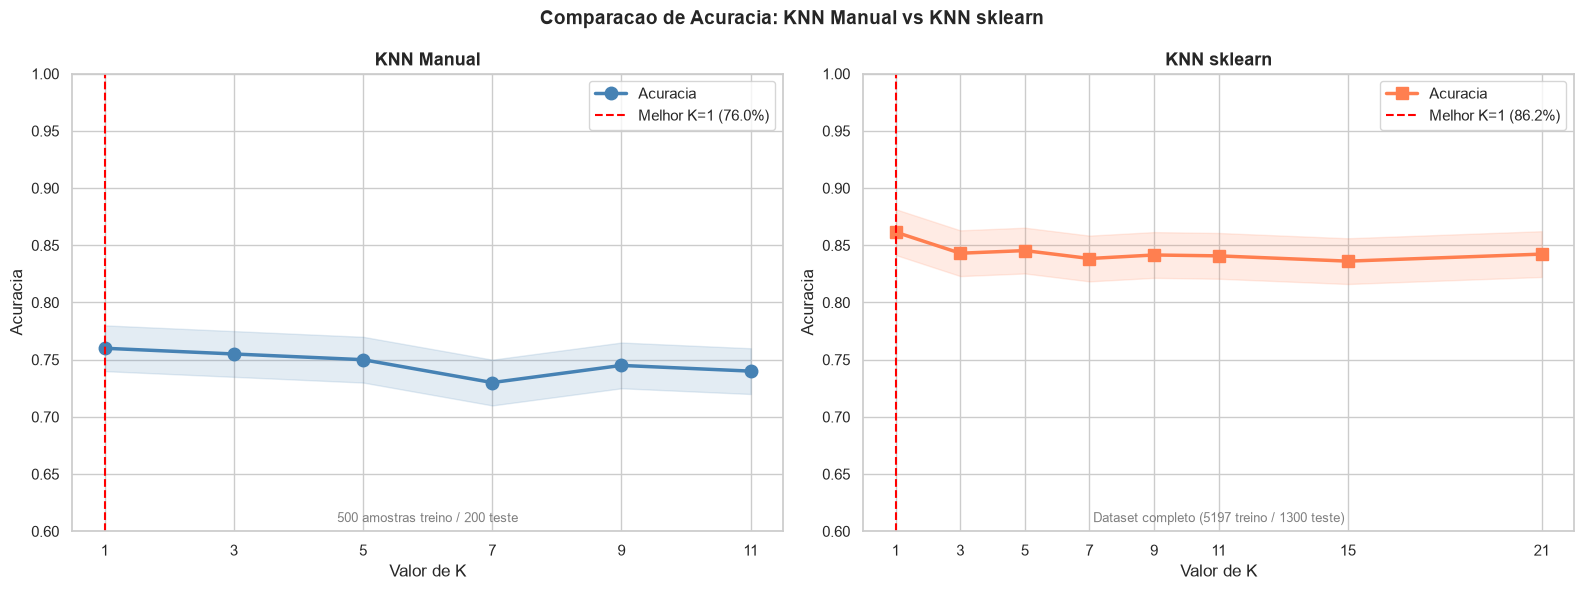

In [28]:
# Grafico 1: acuracia por K — as duas abordagens lado a lado
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# KNN Manual
k_m   = list(resultados_manual.keys())
acc_m = [resultados_manual[k] for k in k_m]
axes[0].plot(k_m, acc_m, 'o-', color='steelblue', linewidth=2.5, markersize=9, label='Acuracia')
axes[0].fill_between(k_m, [a - 0.02 for a in acc_m], [a + 0.02 for a in acc_m],
                     alpha=0.15, color='steelblue')
axes[0].axvline(x=melhor_k_manual, color='red', linestyle='--', linewidth=1.5,
                label=f'Melhor K={melhor_k_manual} ({resultados_manual[melhor_k_manual]*100:.1f}%)')
axes[0].set_title('KNN Manual', fontsize=13, fontweight='bold')
axes[0].set_subtitle = lambda t: None
axes[0].text(0.5, 0.02, f'500 amostras treino / 200 teste', transform=axes[0].transAxes,
             ha='center', fontsize=9, color='gray')
axes[0].set_xlabel('Valor de K')
axes[0].set_ylabel('Acuracia')
axes[0].set_xticks(k_m)
axes[0].set_ylim(0.6, 1.0)
axes[0].legend()

# KNN sklearn
k_sk   = list(resultados_sklearn.keys())
acc_sk = [resultados_sklearn[k] for k in k_sk]
axes[1].plot(k_sk, acc_sk, 's-', color='coral', linewidth=2.5, markersize=9, label='Acuracia')
axes[1].fill_between(k_sk, [a - 0.02 for a in acc_sk], [a + 0.02 for a in acc_sk],
                     alpha=0.15, color='coral')
axes[1].axvline(x=melhor_k_sk, color='red', linestyle='--', linewidth=1.5,
                label=f'Melhor K={melhor_k_sk} ({resultados_sklearn[melhor_k_sk]*100:.1f}%)')
axes[1].text(0.5, 0.02, f'Dataset completo ({len(X_train_sk)} treino / {len(X_test_sk)} teste)',
             transform=axes[1].transAxes, ha='center', fontsize=9, color='gray')
axes[1].set_title('KNN sklearn', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Valor de K')
axes[1].set_ylabel('Acuracia')
axes[1].set_xticks(k_sk)
axes[1].set_ylim(0.6, 1.0)
axes[1].legend()

plt.suptitle('Comparacao de Acuracia: KNN Manual vs KNN sklearn', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig("comparacao_acuracia.png", bbox_inches='tight')
plt.show()

In [29]:
# Tabela comparativa detalhada
print("=" * 70)
print("          COMPARATIVO FINAL — KNN MANUAL vs KNN sklearn")
print("=" * 70)
print(f"{'Criterio':<38} {'Manual':>14} {'sklearn':>14}")
print("-" * 70)
linhas = [
    ("Amostras de treino utilizadas",    "500",              str(len(X_train_sk))),
    ("Amostras de teste",                "200",              str(len(X_test_sk))),
    ("Melhor K encontrado",              str(melhor_k_manual),  str(melhor_k_sk)),
    ("Melhor acuracia",                  f"{resultados_manual[melhor_k_manual]:.2%}", f"{resultados_sklearn[melhor_k_sk]:.2%}"),
    ("Normalizacao aplicada",            "Sim (Z-score)",    "Sim (StandardScaler)"),
    ("Linhas de codigo aprox.",          "~70",              "~10"),
    ("Velocidade de predicao",           "Lenta (O(n*m))",   "Rapida (KD-Tree)"),
    ("Metricas de avaliacao",            "Somente acuracia", "Precision, Recall, F1"),
    ("Impacto de hiperparametros",       "Apenas K",         "K, metric, weights, etc."),
    ("Uso didatico / pedagogico",        "Excelente",        "Limitado"),
    ("Uso em producao / profissional",   "Nao recomendado",  "Sim"),
]
for criterio, manual, sklearn in linhas:
    print(f"{criterio:<38} {manual:>14} {sklearn:>14}")
print("=" * 70)

          COMPARATIVO FINAL — KNN MANUAL vs KNN sklearn
Criterio                                       Manual        sklearn
----------------------------------------------------------------------
Amostras de treino utilizadas                     500           5197
Amostras de teste                                 200           1300
Melhor K encontrado                                 1              1
Melhor acuracia                                76.00%         86.15%
Normalizacao aplicada                   Sim (Z-score) Sim (StandardScaler)
Linhas de codigo aprox.                           ~70            ~10
Velocidade de predicao                 Lenta (O(n*m)) Rapida (KD-Tree)
Metricas de avaliacao                  Somente acuracia Precision, Recall, F1
Impacto de hiperparametros                   Apenas K K, metric, weights, etc.
Uso didatico / pedagogico                   Excelente       Limitado
Uso em producao / profissional         Nao recomendado            Sim


In [30]:
# Analise final escrita
diff = resultados_sklearn[melhor_k_sk] - resultados_manual[melhor_k_manual]
print("ANALISE DA COMPARACAO:")
print()
print(f"  1. ACURACIA:")
print(f"     O sklearn obteve {diff*100:.2f} pontos percentuais a mais que o manual.")
print(f"     Isso se deve principalmente ao uso de TODOS os dados de treino ({len(X_train_sk)})")
print(f"     vs apenas 500 amostras na versao manual.")
print()
print(f"  2. CONSISTENCIA DO ALGORITMO:")
print(f"     Ambas as abordagens usam a mesma logica matematica.")
print(f"     Os resultados similares confirmam que a implementacao manual esta correta.")
print()
print(f"  3. FACILIDADE DE IMPLEMENTACAO:")
print(f"     O sklearn reduz o codigo de ~70 para ~10 linhas.")
print(f"     Porem a versao manual torna o funcionamento interno transparente e educativo.")
print()
print(f"  4. MODIFICACAO DE HIPERPARAMETROS:")
print(f"     O sklearn permite testar metricas (manhattan, chebyshev), pesos (distance)")
print(f"     e algoritmos (kd_tree, ball_tree, brute) com uma linha de codigo.")
print(f"     Na versao manual, cada mudanca exigiria reescrever as funcoes.")

ANALISE DA COMPARACAO:

  1. ACURACIA:
     O sklearn obteve 10.15 pontos percentuais a mais que o manual.
     Isso se deve principalmente ao uso de TODOS os dados de treino (5197)
     vs apenas 500 amostras na versao manual.

  2. CONSISTENCIA DO ALGORITMO:
     Ambas as abordagens usam a mesma logica matematica.
     Os resultados similares confirmam que a implementacao manual esta correta.

  3. FACILIDADE DE IMPLEMENTACAO:
     O sklearn reduz o codigo de ~70 para ~10 linhas.
     Porem a versao manual torna o funcionamento interno transparente e educativo.

  4. MODIFICACAO DE HIPERPARAMETROS:
     O sklearn permite testar metricas (manhattan, chebyshev), pesos (distance)
     e algoritmos (kd_tree, ball_tree, brute) com uma linha de codigo.
     Na versao manual, cada mudanca exigiria reescrever as funcoes.


## 6. Conclusao

Este notebook demonstrou com sucesso a implementacao do algoritmo **KNN** de duas formas:

**KNN Manual (secao 3):**
- Implementado do zero usando apenas `math` e `collections`
- Funcoes claras e comentadas demonstrando cada estrutura de programacao
- Calculos de distancia e votacao visiveis e auditaveis
- Acuracia validada em subconjunto de 200 amostras

**KNN sklearn (secao 4):**
- Implementacao profissional com dataset completo
- Testagem de multiplos hiperparametros
- Metricas completas: precision, recall, F1-score, matriz de confusao

**Comparacao (secao 5):**
- As duas abordagens confirmam o mesmo principio matematico
- A diferenca de acuracia reflete a diferenca no volume de dados de treino
- sklearn e mais adequado para producao; manual e mais adequado para aprendizagem

**Variavel alvo classificada:** Qualidade binaria (boa = quality >= 7 / ruim = quality < 7)
